In [1]:
!echo $LD_LIBRARY_PATH, $CONDA_PREFIX

/hpc/group/cosmology/nlc38/anaconda3/envs/dp2_smhm/lib, /hpc/group/cosmology/nlc38/anaconda3/envs/dp2_smhm


In [ ]:
import pyccl as ccl
import numpy as np
from scipy.integrate import simpsononon
import matplotlib.pyplot as plt

In [8]:
import matplotlib as mpl
mpl.rcParams['font.size'] = 16
mpl.rcParams['text.usetex'] = 'True'

In [41]:
cosmo = ccl.CosmologyVanillaLCDM()

# Here we use a mass definition with Delta = 200 times the matter density,
# Note: We are defining mass w.r.t the matter density, not the critical density, which is more common in some contexts. 
# keep in mind when instantiating base cl.halos.HaloProfileHOD class with mass_def and concentration-mass relation, as both should follow same rho_type convention.
# If they differ, cl.halos.HaloProfileHOD will raise an error, which is good to prevent mistakes.
hmd_200m = ccl.halos.MassDef200m
# The Duffy2008 concentration-mass relation, by default it will be initialized for S.O masses with Delta=Delta_vir of Delta_vir=200
# critical density based halo mass :math:`M_{200c}`.  (Evolution of Mvir (SO based mass even when Delta is fixed to 200) with redshift is shown below.)
cM = ccl.halos.ConcentrationDuffy08(mass_def=hmd_200m)
assert cM.mass_def == hmd_200m, "This is what you've to be careful of!"
assert cM.mass_def.name == hmd_200m.name, "Same issue"

In [32]:
hmd_200m?

Type:        MassDef
String form: MassDef(Delta=200, rho_type=matter)
File:        /hpc/group/cosmology/nlc38/anaconda3/envs/dp2_smhm/lib/python3.14/site-packages/pyccl/halos/massdef.py
Docstring:  
Halo mass definition. Halo masses are defined in terms of an overdensity
parameter :math:`\Delta` and an associated density :math:`X` (either the
matter density or the critical density):

.. math::
    M_\Delta = \frac{4 \pi}{3} \Delta\,\rho_X\, R_\Delta^3

where :math:`R_\Delta` is the halo radius. This object also holds methods
to translate between :math:`R_\Delta` and :math:`M_\Delta`, and to
translate masses between different definitions if a concentration-mass
relation is provided.

You may also define halo masses based on a Friends-of-Friends algorithm,
in which case simply pass ``Delta='fof'`` below.

Args:
    Delta (:obj:`float`): overdensity parameter. Pass ``'vir'`` if using virial
        overdensity. Pass ``'fof'`` for Friends-of-Friends halos.
    rho_type (:obj:`str`): either

### How the $M_{vir}$ changes with redshift even if you keep the $\Delta=200$ fixed.

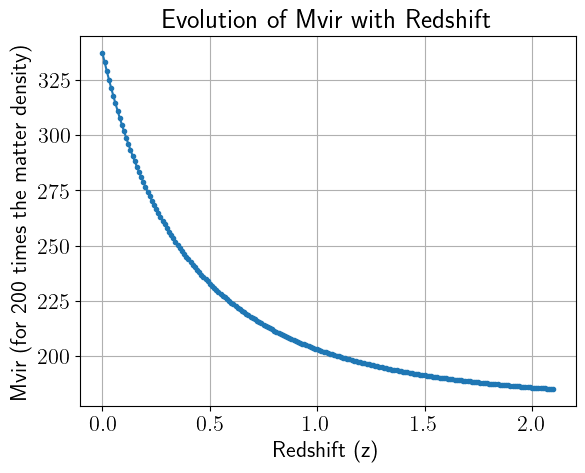

In [31]:
# Checking how Mvir evolves with redshift for this cosmology and fixed mass definition of 200 times the matter density.
z = np.linspace(0, 2.1, 211)
aa = 1/(1+z)
mvir=[]
for a in aa:
    mvir.append(hmd_200m.get_Delta_vir(cosmo, a))

plt.plot(z, mvir, ".-")
plt.xlabel('Redshift (z)')
plt.ylabel('Mvir (for 200 times the matter density)')
plt.title('Evolution of Mvir with Redshift')
plt.grid()
plt.savefig("Mvir_vs_scaleFactor_for_M200m_mass_def.png", bbox_inches='tight', dpi=200)

In [46]:
from typing import Union, Optional

class CacciatoHOD(ccl.halos.HaloProfileHOD):
    def __init__(self, *, 
                 mass_def: Union[str, ccl.halos.MassDef], 
                 cM_rel: Union[str, ccl.halos.Concentration],
                 Lmin, Lmax, N_L=64,
                 lL_0=9.95, lM_1=11.24,
                 gamma_1=3.18, gamma_2=0.245,
                 sigma_c=0.157, alpha_s=-1.18,
                 b_0=-1.17, b_1=1.53*0.739, b_2=-0.217*0.739**2,
                 fh=1., fs=1.
                 ) -> None:
        """
        Custom HOD model based on Cacciato et al.
        
        Args:
            mass_def: Halo mass definition (e.g., '200m' or a MassDef object).
            cM_rel: Concentration-mass relation (e.g., 'Duffy08' or a Concentration object).
            **kwargs: Additional HOD parameters passed to the parent class.
        """
        # Initialize the parent class with essential parameters
        # overwrite more parent attr if you need.
        super().__init__(mass_def=mass_def, concentration=cM_rel)

        # fh, fs the scaling of cM_rel, to be include in _usat_real/fourier
        # b_1 and b_2 have been rescaled by h from Cacciato et al. 2013
        self.cM = cM_rel

        self.Lmin = Lmin
        self.Lmax = Lmax
        self.N_L = N_L
        self.L_arr = np.geomspace(self.Lmin, self.Lmax, self.N_L)

        self.lL_0 = lL_0
        self.L_0 = 10**lL_0
        self.lM_1 = lM_1
        self.M_1 = 10**lM_1
        self.gamma_1 = gamma_1
        self.gamma_2 = gamma_2
        self.sigma_c = sigma_c
        self.alpha_s = alpha_s
        self.b_0 = b_0
        self.b_1 = b_1
        self.b_2 = b_2
        self.loge = 0.4342944819 # logarithm of e

    def _Lc(self, M):
        return self.L_0 * (M/self.M_1) ** self.gamma_1 /\
               (1+(M/self.M_1)**(self.gamma_1-self.gamma_2))

    def _phi_star_s(self, M):
        M12 = M/10**12 # In solar masses
        log_phi_star_s = self.b_0+self.b_1*np.log10(M12)+self.b_2*np.log10(M12)**2
        return 10**log_phi_star_s

    def _L_star_s(self, M):
        return 0.562 * self._Lc(M)

    def conditional_luminosity_function_central(self, L, M):
        L_use = np.atleast_1d(L).reshape(1, -1)
        M_use = np.atleast_1d(M).reshape(-1, 1)
        return self.loge/(np.sqrt(2*np.pi)*self.sigma_c) * \
               np.exp(-(np.log10(L_use)-np.log10(self._Lc(M_use)))**2 /\
                        (2*self.sigma_c**2)) / L_use

    def conditional_luminosity_function_satellite(self, L, M):
        L_use = np.atleast_1d(L).reshape(1, -1)
        M_use = np.atleast_1d(M).reshape(-1, 1)
        return self._phi_star_s(M_use)/L_use * (L_use/self._L_star_s(M_use))**(self.alpha_s+1) * \
               np.exp(-(L_use/self._L_star_s(M_use))**2)

    # updating the parent default HOD methods for specific usecase here
    def _Nc(self, M, a):
        return simpson(
            self.conditional_luminosity_function_central(self.L_arr, M),
            self.L_arr)

    def _Ns(self, M, a):
        return simpson(
            self.conditional_luminosity_function_satellite(self.L_arr, M),
            self.L_arr)

In [47]:
hod = CacciatoHOD(mass_def=hmd_200m, cM_rel=cM, Lmin=1.5e7, Lmax=5.6e9)
mass_arr = np.geomspace(1e8, 1e16, 128)
Ns = hod._Ns(mass_arr, 1.)
Nc = hod._Nc(mass_arr, 1.)

<>:6: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:6: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/tmp/ipykernel_959148/2276955432.py:6: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  ax.set_xlabel('$M$ [M$_\odot$]')


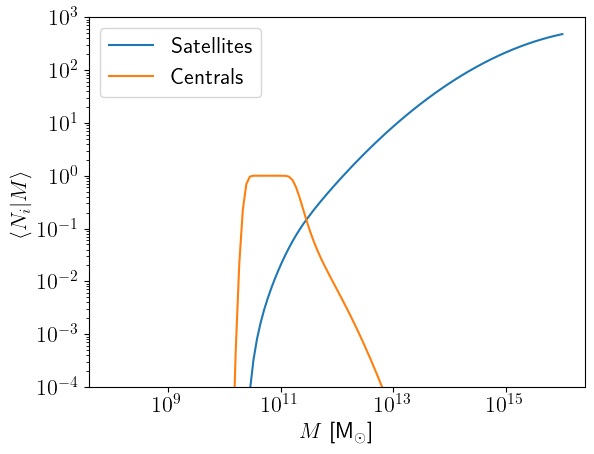

In [53]:
fig, ax = plt.subplots()
ax.loglog(mass_arr, Ns, label='Satellites')
ax.loglog(mass_arr, Nc, label='Centrals')
ax.set_ylim([1e-4, 1e3])
ax.legend()
ax.set_xlabel('$M$ [M$_\odot$]')
ax.set_ylabel(r'$\langle N_i|M \rangle$')
plt.savefig("Cacciato_HOD_Nc_Ns_vs_M.pdf", bbox_inches='tight', dpi=200)

My explorations with CCL